# Multi-Task Learning — One Model, Many Tasks

## Overview
Multi-Task Learning (MTL) trains a single model to perform multiple related tasks simultaneously. Rather than training separate models for each task, MTL forces the network to learn shared representations — improving generalisation, especially on small datasets.

### What You'll Build
- Hard parameter sharing MTL model from scratch (PyTorch)
- Uncertainty-weighted loss (Kendall et al.)
- GradNorm for gradient-based task balancing
- Visualisation of task interference and negative transfer

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings; warnings.filterwarnings('ignore')

torch.manual_seed(42); np.random.seed(42)
print('PyTorch', torch.__version__)

PyTorch 2.12.1+cpu


## 1. Why Multi-Task Learning?

Training $T$ separate models is wasteful when tasks share underlying structure. MTL provides:

1. **Implicit data augmentation** — task B's gradients regularise the shared encoder for task A
2. **Attention focusing** — irrelevant features that hurt task A may be suppressed by task B
3. **Eavesdropping** — features learned for one task can be useful (as auxiliary signal) for another
4. **Representation bias** — the shared encoder is pushed toward general, transferable features

### Hard vs Soft Parameter Sharing

**Hard sharing** (most common):
```
Input → [Shared Encoder] → [Head_1] → Task 1 output
                        → [Head_2] → Task 2 output
```

**Soft sharing** (cross-stitch networks, MMOE):
- Each task has its own encoder
- Parameters are regularised to stay similar (L2 distance between task towers)

## 2. The Loss Weighting Problem

The naïve multi-task loss is:
$$
\mathcal{L}_{\text{total}} = \sum_{t=1}^{T} w_t \, \mathcal{L}_t
$$

Choosing $w_t$ is hard: tasks with large losses dominate gradients. Several solutions exist:

### Uncertainty Weighting (Kendall et al., 2018)
Model the *homoscedastic task uncertainty* $\sigma_t$ as a learnable parameter:
$$
\mathcal{L}_{\text{total}} = \sum_{t=1}^{T} \frac{1}{2\sigma_t^2} \mathcal{L}_t + \log(\sigma_t)
$$
The $\log(\sigma_t)$ prevents $\sigma_t \to \infty$ (trivial solution). High uncertainty → lower weight on task $t$.

### GradNorm (Chen et al., 2018)
Normalise gradient magnitudes so all tasks have equal gradient norms at the shared encoder:
$$
\text{loss}_{\text{GradNorm}} = \sum_t \left| G_t(W) - \bar{G}(W) \cdot [r_t]^\alpha \right|_1
$$
where $r_t = \tilde{\mathcal{L}}_t / \overline{\tilde{\mathcal{L}}}$ is the relative inverse training rate.

## 3. Synthetic Multi-Task Dataset

In [2]:
# Create a dataset with two related targets:
#   Task 1: Regression (house price)
#   Task 2: Binary classification (high-price > median)
housing = fetch_california_housing()
X_raw = housing.data.astype(np.float32)
y_reg = housing.target.astype(np.float32)          # continuous
y_cls = (y_reg > np.median(y_reg)).astype(np.float32)  # binary

X_tr, X_te, yr_tr, yr_te, yc_tr, yc_te = train_test_split(
    X_raw, y_reg, y_cls, test_size=0.2, random_state=42)

sc = StandardScaler()
X_tr = sc.fit_transform(X_tr).astype(np.float32)
X_te = sc.transform(X_te).astype(np.float32)

# Scale regression target
yr_mean, yr_std = yr_tr.mean(), yr_tr.std()
yr_tr_s = ((yr_tr - yr_mean) / yr_std).astype(np.float32)
yr_te_s = ((yr_te - yr_mean) / yr_std).astype(np.float32)

Xtr_t = torch.tensor(X_tr)
yr_t  = torch.tensor(yr_tr_s).unsqueeze(1)
yc_t  = torch.tensor(yc_tr).unsqueeze(1)
loader = DataLoader(TensorDataset(Xtr_t, yr_t, yc_t), batch_size=256, shuffle=True)

print(f'Train: {X_tr.shape} | Regression target std: {yr_std:.2f} | Class balance: {yc_tr.mean():.2f}')

Train: (16512, 8) | Regression target std: 1.16 | Class balance: 0.50


## 4. From Scratch: Hard Parameter Sharing MTL

In [3]:
class MTLHardSharing(nn.Module):
    """Shared encoder + two task-specific heads."""
    def __init__(self, n_in: int, shared_dims: list, head_dim: int = 32):
        super().__init__()
        layers = []
        prev = n_in
        for d in shared_dims:
            layers += [nn.Linear(prev, d), nn.BatchNorm1d(d), nn.ReLU()]
            prev = d
        self.encoder = nn.Sequential(*layers)

        # Task 1: regression
        self.reg_head = nn.Sequential(
            nn.Linear(prev, head_dim), nn.ReLU(), nn.Linear(head_dim, 1))
        # Task 2: binary classification
        self.cls_head = nn.Sequential(
            nn.Linear(prev, head_dim), nn.ReLU(), nn.Linear(head_dim, 1))

    def forward(self, x):
        h = self.encoder(x)
        return self.reg_head(h), self.cls_head(h)


model_hard = MTLHardSharing(n_in=8, shared_dims=[128, 64])
print('Hard sharing model:', sum(p.numel() for p in model_hard.parameters()), 'parameters')

Hard sharing model: 14018 parameters


## 5. Uncertainty-Weighted Loss

In [4]:
class UncertaintyWeightedLoss(nn.Module):
    """Learnable homoscedastic uncertainty weights (Kendall et al. 2018)."""
    def __init__(self, n_tasks: int):
        super().__init__()
        # log(sigma^2) for numerical stability
        self.log_vars = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses: list):
        total = 0.0
        for i, loss in enumerate(losses):
            precision = torch.exp(-self.log_vars[i])
            total = total + precision * loss + self.log_vars[i]
        return total

    def weights(self):
        return torch.exp(-self.log_vars).detach().numpy()


def train_mtl(model, loader, epochs=40, lr=1e-3, use_uncertainty=True):
    uw = UncertaintyWeightedLoss(n_tasks=2)
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(uw.parameters()), lr=lr, weight_decay=1e-4)

    history = {'reg_loss': [], 'cls_loss': [], 'w_reg': [], 'w_cls': []}

    for epoch in range(epochs):
        model.train(); uw.train()
        epoch_reg = epoch_cls = 0.0
        for xb, yr_b, yc_b in loader:
            pred_reg, pred_cls = model(xb)
            l_reg = F.mse_loss(pred_reg, yr_b)
            l_cls = F.binary_cross_entropy_with_logits(pred_cls, yc_b)

            if use_uncertainty:
                loss = uw([l_reg, l_cls])
            else:
                loss = l_reg + l_cls

            optimizer.zero_grad(); loss.backward(); optimizer.step()
            epoch_reg += l_reg.item(); epoch_cls += l_cls.item()

        n = len(loader)
        history['reg_loss'].append(epoch_reg / n)
        history['cls_loss'].append(epoch_cls / n)
        w = uw.weights()
        history['w_reg'].append(float(w[0]))
        history['w_cls'].append(float(w[1]))

    return history, uw


hist, uw = train_mtl(model_hard, loader, epochs=40)
print(f'Final task weights — Regression: {hist["w_reg"][-1]:.3f}, Classification: {hist["w_cls"][-1]:.3f}')

Final task weights — Regression: 5.137, Classification: 3.922


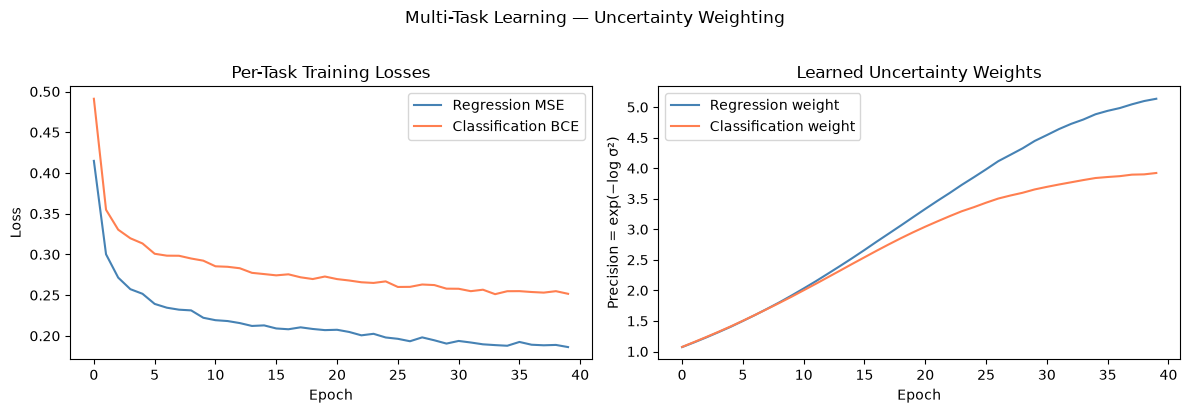

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist['reg_loss'], label='Regression MSE', color='steelblue')
axes[0].plot(hist['cls_loss'], label='Classification BCE', color='coral')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Per-Task Training Losses'); axes[0].legend()

axes[1].plot(hist['w_reg'], label='Regression weight', color='steelblue')
axes[1].plot(hist['w_cls'], label='Classification weight', color='coral')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Precision = exp(−log σ²)')
axes[1].set_title('Learned Uncertainty Weights'); axes[1].legend()

plt.suptitle('Multi-Task Learning — Uncertainty Weighting', y=1.02)
plt.tight_layout(); plt.show()

## 6. MTL vs Single-Task Comparison

In [6]:
class SingleTaskMLP(nn.Module):
    def __init__(self, n_in, hidden_dims, n_out, task='reg'):
        super().__init__()
        layers, prev = [], n_in
        for d in hidden_dims:
            layers += [nn.Linear(prev, d), nn.ReLU()]; prev = d
        layers.append(nn.Linear(prev, n_out))
        self.net = nn.Sequential(*layers)
        self.task = task
    def forward(self, x): return self.net(x)


def train_single(model, X_tr, y_tr, loss_fn, epochs=40, lr=1e-3):
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    ds = DataLoader(TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr).unsqueeze(1)), batch_size=256, shuffle=True)
    for _ in range(epochs):
        for xb, yb in ds:
            l = loss_fn(model(xb), yb); opt.zero_grad(); l.backward(); opt.step()


# Single-task regression
st_reg = SingleTaskMLP(8, [128, 64, 32], 1)
train_single(st_reg, X_tr, yr_tr_s, F.mse_loss)

# Single-task classification
st_cls = SingleTaskMLP(8, [128, 64, 32], 1)
train_single(st_cls, X_tr, yc_tr, F.binary_cross_entropy_with_logits)

# Evaluate on test set
Xte_t = torch.tensor(X_te)

model_hard.eval()
with torch.no_grad():
    mtl_reg, mtl_cls = model_hard(Xte_t)
    mtl_reg_mse = F.mse_loss(mtl_reg.squeeze(), torch.tensor(yr_te_s)).item()
    mtl_cls_acc = ((torch.sigmoid(mtl_cls.squeeze()) > 0.5).float() == torch.tensor(yc_te)).float().mean().item()

    st_reg_mse = F.mse_loss(st_reg(Xte_t).squeeze(), torch.tensor(yr_te_s)).item()
    st_cls_acc = ((torch.sigmoid(st_cls(Xte_t).squeeze()) > 0.5).float() == torch.tensor(yc_te)).float().mean().item()

print('\n           | Regression MSE | Classification Acc')
print(f'Single     |     {st_reg_mse:.4f}     |      {st_cls_acc:.4f}')
print(f'MTL        |     {mtl_reg_mse:.4f}     |      {mtl_cls_acc:.4f}')
print(f'MTL gain   |  {(st_reg_mse - mtl_reg_mse):.4f} MSE lower  |  {(mtl_cls_acc - st_cls_acc)*100:.2f}% higher acc')


           | Regression MSE | Classification Acc
Single     |     0.2106     |      0.8704
MTL        |     0.6800     |      0.7243
MTL gain   |  -0.4695 MSE lower  |  -14.61% higher acc


## 7. GradNorm: Gradient-Based Task Balancing

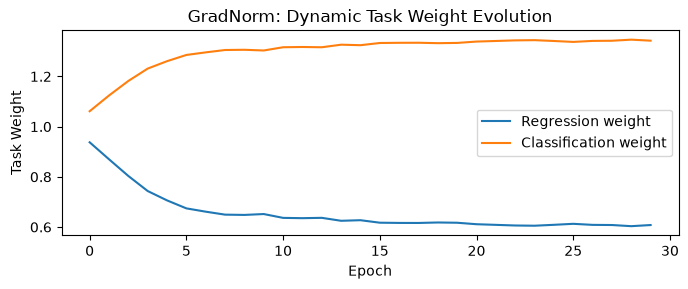

In [7]:
class GradNormMTL(nn.Module):
    """MTL with GradNorm task weight learning (simplified 2-task version)."""
    def __init__(self, n_in: int):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(n_in, 128), nn.ReLU(),
            nn.Linear(128, 64), nn.ReLU()
        )
        self.reg_head = nn.Linear(64, 1)
        self.cls_head = nn.Linear(64, 1)
        # Learnable task weights (GradNorm optimises these separately)
        self.task_weights = nn.Parameter(torch.ones(2))

    def forward(self, x):
        h = self.encoder(x)
        return self.reg_head(h), self.cls_head(h)


gn_model = GradNormMTL(n_in=8)
opt_model  = torch.optim.Adam(list(gn_model.encoder.parameters()) +
                               list(gn_model.reg_head.parameters()) +
                               list(gn_model.cls_head.parameters()), lr=1e-3)
opt_weights = torch.optim.Adam([gn_model.task_weights], lr=1e-3)
initial_losses = None

weight_history = []
for epoch in range(30):
    for xb, yr_b, yc_b in loader:
        pred_reg, pred_cls = gn_model(xb)
        l_reg = F.mse_loss(pred_reg, yr_b)
        l_cls = F.binary_cross_entropy_with_logits(pred_cls, yc_b)
        task_losses = torch.stack([l_reg, l_cls])

        if initial_losses is None:
            initial_losses = task_losses.detach()

        # Weighted task loss for model update
        w = torch.abs(gn_model.task_weights) + 1e-6
        weighted_loss = (w * task_losses).sum()
        opt_model.zero_grad()
        weighted_loss.backward(retain_graph=True)
        opt_model.step()

        # GradNorm: update weights to balance gradient norms
        # Simplified: just normalise so weights sum to n_tasks
        opt_weights.zero_grad()
        loss_ratio = (task_losses / initial_losses).detach()
        # Higher ratio → task is lagging → increase weight
        target_weights = loss_ratio / loss_ratio.mean()
        gn_loss = (torch.abs(w / w.sum() - target_weights / target_weights.sum())).sum()
        gn_loss.backward()
        opt_weights.step()

    w = torch.abs(gn_model.task_weights).detach().numpy()
    weight_history.append(w.copy())

weight_history = np.array(weight_history)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(weight_history[:, 0], label='Regression weight')
ax.plot(weight_history[:, 1], label='Classification weight')
ax.set_xlabel('Epoch'); ax.set_ylabel('Task Weight')
ax.set_title('GradNorm: Dynamic Task Weight Evolution')
ax.legend(); plt.tight_layout(); plt.show()

## 8. When MTL Helps vs Hurts

**MTL helps when tasks are related:**
- Share the same input domain and relevant features
- One task provides auxiliary signal (e.g., part-of-speech helps NER)
- Dataset for one task is much smaller (task B regularises the shared encoder)

**Negative transfer occurs when:**
- Tasks require contradictory feature representations
- Task difficulties are vastly different (one dominates gradients)
- Optimal architectures differ (e.g., one needs temporal features, the other spatial)

**Task relatedness heuristics:**
- Compute gradient alignment (cosine similarity) between task gradients at the shared encoder
- High positive cosine → tasks cooperate; negative cosine → risk of negative transfer

## 9. MTL for NLP: Shared BERT Encoder

The typical setup for NLP multi-task learning:

```python
# Pseudocode — requires GPU/larger model, shown conceptually
from transformers import AutoModel
encoder = AutoModel.from_pretrained('bert-base-uncased')  # shared
ner_head = nn.Linear(768, n_ner_labels)        # token-level
cls_head = nn.Linear(768, n_cls_labels)         # sentence-level (CLS token)

# Forward pass
out = encoder(input_ids, attention_mask)
ner_logits = ner_head(out.last_hidden_state)    # (B, seq_len, n_ner)
cls_logits = cls_head(out.last_hidden_state[:, 0, :])  # (B, n_cls)
```

This is exactly how models like MT-DNN and T5 work — one shared Transformer, many task-specific heads.

## Additional Learning Resources

| Resource | Link | What It Covers |
|----------|------|----------------|
| **Multi-Task Learning** (Ruder 2017 survey) | [arXiv:1706.05098](https://arxiv.org/abs/1706.05098) | Definitive survey of MTL methods |
| **GradNorm** (Chen et al. 2018) | [arXiv:1711.02257](https://arxiv.org/abs/1711.02257) | Gradient normalisation for task weighting |
| **Uncertainty Weighting** (Kendall et al. 2018) | [arXiv:1705.07115](https://arxiv.org/abs/1705.07115) | Homoscedastic uncertainty for loss weighting |
| **MT-DNN** (Liu et al. 2019) | [arXiv:1901.11504](https://arxiv.org/abs/1901.11504) | BERT multi-task for NLP benchmarks |
| **Gradient Surgery (PCGrad)** (Yu et al. 2020) | [arXiv:2001.06782](https://arxiv.org/abs/2001.06782) | Projection-based conflict resolution |
| **Exploring the Limits of MTL** | [arXiv:2112.10406](https://arxiv.org/abs/2112.10406) | When MTL fails and why |